# Demonstration of finding tie-triangle

This is a toy problem of find tie-triagnle in a ternary system. The code is generated by GPT 5.2.

Chemical potential is obtained by
$$\mu_i = \frac{\partial G}{\partial x_i}$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import mpltern

# ============================================================
# 1. Toy ternary free energy with three minima
#    Independent variables: xA, xB
#    xC = 1 - xA - xB
# ============================================================

def G_toy(xA, xB):
    xC = 1.0 - xA - xB

    # reject invalid compositions
    if np.any(xA < 0) or np.any(xB < 0) or np.any(xC < 0):
        return np.inf

    # three target minima (in ternary composition space)
    p1 = np.array([0.70, 0.15])   # xC = 0.15
    p2 = np.array([0.15, 0.70])   # xC = 0.15
    p3 = np.array([0.15, 0.15])   # xC = 0.70

    # background convex term
    G0 = 0.4 * ((xA - 1/3)**2 + (xB - 1/3)**2)

    # three Gaussian wells
    s2 = 0.01
    well1 = -1.0 * np.exp(-((xA - p1[0])**2 + (xB - p1[1])**2) / s2)
    well2 = -1.0 * np.exp(-((xA - p2[0])**2 + (xB - p2[1])**2) / s2)
    well3 = -1.0 * np.exp(-((xA - p3[0])**2 + (xB - p3[1])**2) / s2)

    return G0 + well1 + well2 + well3


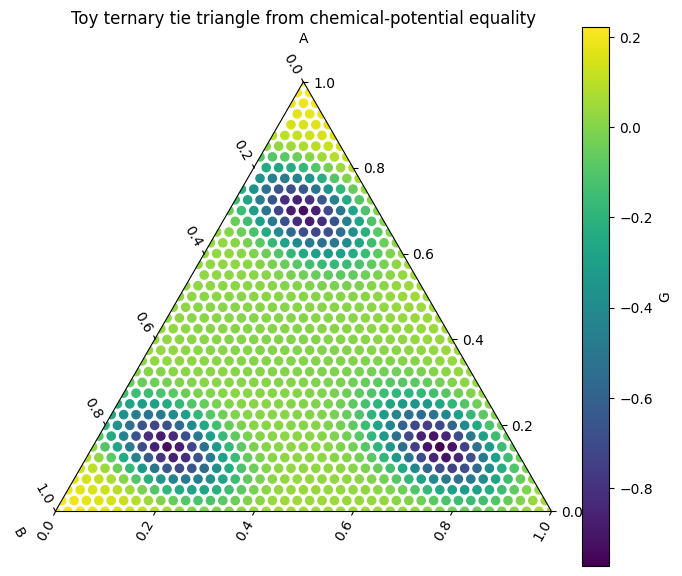

In [4]:
# ============================================================
# 2. Plot the toy free energy and tie triangle
# ============================================================

# build a ternary grid
pts = []
Gvals = []
n = 40
for i in range(n + 1):
    for j in range(n + 1 - i):
        xA = i / n
        xB = j / n
        xC = 1.0 - xA - xB
        pts.append((xA, xB, xC))
        Gvals.append(G_toy(xA, xB))

pts = np.array(pts)
Gvals = np.array(Gvals)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="ternary")

sc = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=Gvals, s=35)

# tri_closed = np.vstack([tie_triangle, tie_triangle[0]])
# ax.plot(tri_closed[:, 0], tri_closed[:, 1], tri_closed[:, 2], 'r-', lw=3)
# ax.scatter(tie_triangle[:, 0], tie_triangle[:, 1], tie_triangle[:, 2], c='red', s=90)

ax.set_tlabel("A")
ax.set_llabel("B")
ax.set_rlabel("C")
ax.set_title("Toy ternary tie triangle from chemical-potential equality")

plt.colorbar(sc, ax=ax, label="G")
plt.show()

In [6]:
# ============================================================
# 3. Numerical chemical potentials
#    mu_A = dG/dxA, mu_B = dG/dxB
# ============================================================

def chemical_potentials(xA, xB, h=1e-6):
    # central differences
    muA = (G_toy(xA + h, xB) - G_toy(xA - h, xB)) / (2*h)
    muB = (G_toy(xA, xB + h) - G_toy(xA, xB - h)) / (2*h)
    return muA, muB


# ============================================================
# 3. Residuals for 3-phase equilibrium
#    Unknowns:
#      alpha: (xA1, xB1)
#      beta : (xA2, xB2)
#      gamma: (xA3, xB3)
#
#    Conditions:
#      mu_A^alpha = mu_A^beta = mu_A^gamma
#      mu_B^alpha = mu_B^beta = mu_B^gamma
#
#    We also add small penalties to keep points near the wells.
# ============================================================

targets = np.array([
    [0.70, 0.15],
    [0.15, 0.70],
    [0.15, 0.15],
])

def residuals(p):
    xA1, xB1, xA2, xB2, xA3, xB3 = p

    comps = np.array([
        [xA1, xB1],
        [xA2, xB2],
        [xA3, xB3],
    ])

    # composition validity penalties
    penalty = []
    for xA, xB in comps:
        xC = 1.0 - xA - xB
        # keep inside ternary domain
        penalty.append(max(0.0, -xA))
        penalty.append(max(0.0, -xB))
        penalty.append(max(0.0, -xC))

    muA1, muB1 = chemical_potentials(xA1, xB1)
    muA2, muB2 = chemical_potentials(xA2, xB2)
    muA3, muB3 = chemical_potentials(xA3, xB3)

    res = [
        muA1 - muA2,
        muA1 - muA3,
        muB1 - muB2,
        muB1 - muB3,
    ]

    # weak anchoring to keep each phase near one basin
    # purely for this toy example, to select the intended solution branch
    anchor_weight = 0.2
    for (xA, xB), (tA, tB) in zip(comps, targets):
        res.append(anchor_weight * (xA - tA))
        res.append(anchor_weight * (xB - tB))

    # strong penalty if outside domain
    penalty_weight = 100.0
    for q in penalty:
        res.append(penalty_weight * q)

    return np.array(res)

In [8]:
# ============================================================
# 4. Solve for tie-triangle vertices
# ============================================================

# initial guess near the three wells
p0 = np.array([
    0.68, 0.16,   # alpha
    0.16, 0.68,   # beta
    0.16, 0.16,   # gamma
])

sol = least_squares(residuals, p0, verbose=1, xtol=1e-12, ftol=1e-12, gtol=1e-12)
p = sol.x

xA1, xB1, xA2, xB2, xA3, xB3 = p
tie_triangle = np.array([
    [xA1, xB1, 1 - xA1 - xB1],
    [xA2, xB2, 1 - xA2 - xB2],
    [xA3, xB3, 1 - xA3 - xB3],
])

print("\nTie-triangle vertices [xA, xB, xC]:")
print(tie_triangle)

print("\nChemical potentials at the three vertices:")
for i, (xA, xB, xC) in enumerate(tie_triangle, start=1):
    muA, muB = chemical_potentials(xA, xB)
    print(f"Phase {i}: muA = {muA:.6f}, muB = {muB:.6f}")

`xtol` termination condition is satisfied.
Function evaluations 16, initial cost 4.2308e+01, final cost 1.2810e-07, first-order optimality 2.53e-08.

Tie-triangle vertices [xA, xB, xC]:
[[0.69853894 0.15073076 0.1507303 ]
 [0.15073075 0.69853895 0.1507303 ]
 [0.15073064 0.15073065 0.69853872]]

Chemical potentials at the three vertices:
Phase 1: muA = 0.000030, muB = 0.000032
Phase 2: muA = 0.000030, muB = 0.000032
Phase 3: muA = 0.000030, muB = 0.000032


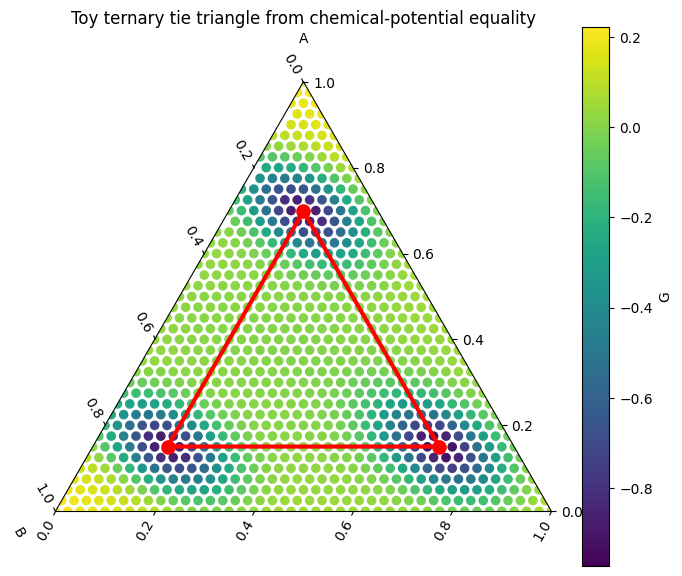

In [10]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="ternary")

sc = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=Gvals, s=35)

tri_closed = np.vstack([tie_triangle, tie_triangle[0]])
ax.plot(tri_closed[:, 0], tri_closed[:, 1], tri_closed[:, 2], 'r-', lw=3)
ax.scatter(tie_triangle[:, 0], tie_triangle[:, 1], tie_triangle[:, 2], c='red', s=90)

ax.set_tlabel("A")
ax.set_llabel("B")
ax.set_rlabel("C")
ax.set_title("Toy ternary tie triangle from chemical-potential equality")

plt.colorbar(sc, ax=ax, label="G")
plt.show()